In [1]:
import sys
sys.path.append("../src")

import pandas as pd
from cfb_upsets.features import add_upset_label, upset_label_summary

df = pd.read_csv("../data/processed/games_clean_all.csv")
df = add_upset_label(df)
upset_label_summary(df)

Total games: 3945
  Upsets:          1079 (27.4%)
  Non-upsets:      2863 (72.6%)
  Excluded (no favorite / missing spread): 3 (0.1%)


In [2]:
season_upset_rate = df.groupby("season")["upset"].mean()
df["upset"] = pd.to_numeric(df["upset"], errors="coerce")
print(season_upset_rate)

season
2021    0.272727
2022    0.276129
2023    0.268015
2024    0.286967
2025    0.264851
Name: upset, dtype: object


In [3]:
df["spread_magnitude"] = df["spread"].abs()

bins = [0, 3, 7, 14, 21, 100]
labels = ["0-3", "3-7", "7-14", "14-21", "21+"]
df["spread_bucket"] = pd.cut(df["spread_magnitude"], bins=bins, labels=labels)

bucket_upset_rate = df.groupby("spread_bucket")["upset"].mean()
print(bucket_upset_rate)

spread_bucket
0-3      0.464789
3-7      0.352427
7-14     0.236125
14-21    0.110915
21+      0.045908
Name: upset, dtype: float64


In [4]:
print(df["spread_bucket"].value_counts().sort_index())

spread_bucket
0-3       852
3-7      1030
7-14      991
14-21     568
21+       501
Name: count, dtype: int64


In [5]:
underdog_location_rate = df[df["favorite"].notna()].groupby(
    df["favorite"].map({"home": "away", "away": "home"})
)["upset"].mean()

print(underdog_location_rate)

favorite
away    0.251024
home    0.310667
Name: upset, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

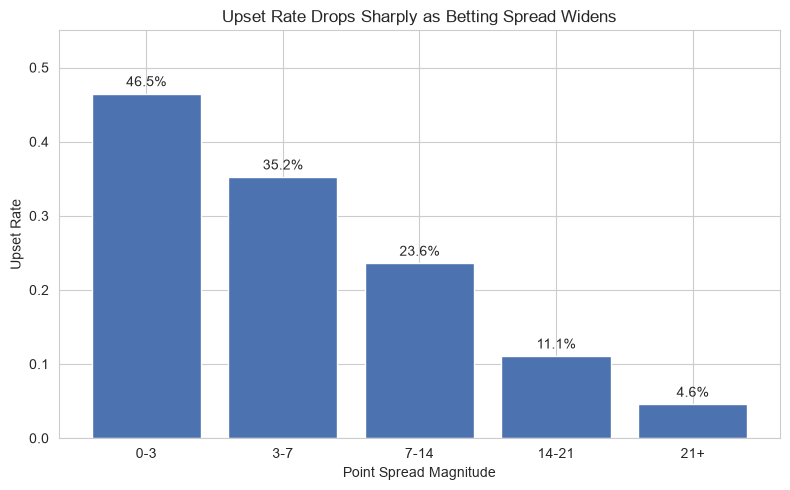

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
bucket_upset_rate = df.groupby("spread_bucket")["upset"].mean()

ax.bar(bucket_upset_rate.index.astype(str), bucket_upset_rate.values, color="#4C72B0")
ax.set_xlabel("Point Spread Magnitude")
ax.set_ylabel("Upset Rate")
ax.set_title("Upset Rate Drops Sharply as Betting Spread Widens")
ax.set_ylim(0, 0.55)

for i, v in enumerate(bucket_upset_rate.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.savefig("../reports/figures/upset_rate_by_spread.png", dpi=150)
plt.show()

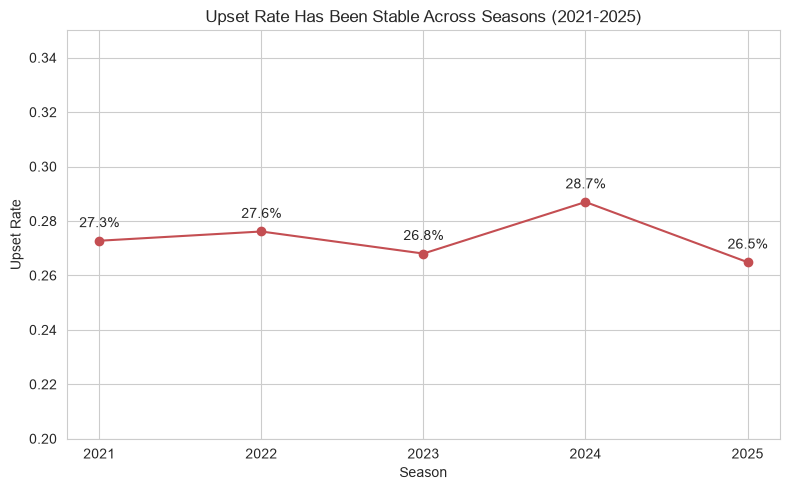

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
season_upset_rate = df.groupby("season")["upset"].mean()

ax.plot(season_upset_rate.index, season_upset_rate.values, marker="o", color="#C44E52")
ax.set_xlabel("Season")
ax.set_ylabel("Upset Rate")
ax.set_title("Upset Rate Has Been Stable Across Seasons (2021-2025)")
ax.set_ylim(0.2, 0.35)
ax.set_xticks(season_upset_rate.index)

for x, y in zip(season_upset_rate.index, season_upset_rate.values):
    ax.text(x, y + 0.005, f"{y:.1%}", ha="center")

plt.tight_layout()
plt.savefig("../reports/figures/upset_rate_by_season.png", dpi=150)
plt.show()

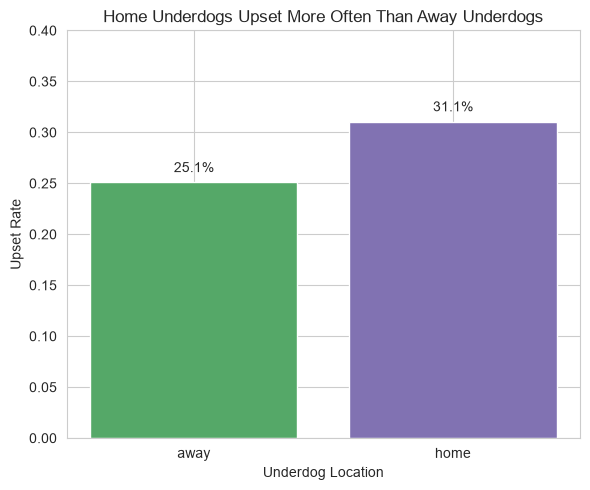

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
underdog_location_rate = df[df["favorite"].notna()].groupby(
    df["favorite"].map({"home": "away", "away": "home"})
)["upset"].mean()

ax.bar(underdog_location_rate.index, underdog_location_rate.values, color=["#55A868", "#8172B2"])
ax.set_xlabel("Underdog Location")
ax.set_ylabel("Upset Rate")
ax.set_title("Home Underdogs Upset More Often Than Away Underdogs")
ax.set_ylim(0, 0.4)

for i, v in enumerate(underdog_location_rate.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.savefig("../reports/figures/upset_rate_home_vs_away_underdog.png", dpi=150)
plt.show()

In [10]:
underdog_conference = df["favorite"].map({"home": "away", "away": "home"})

df["underdog_conference"] = df.apply(
    lambda row: row["awayConference"] if underdog_conference[row.name] == "away" else row["homeConference"],
    axis=1
)

conf_upset_rate = (
    df[df["favorite"].notna()]
    .groupby("underdog_conference")["upset"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

print(conf_upset_rate)

                         mean  count
underdog_conference                 
Big 12               0.328652    356
ACC                  0.316901    426
Sun Belt             0.314010    414
SEC                  0.286885    366
Conference USA       0.265464    388
Mid-American         0.255924    422
FBS Independents     0.250000    136
Mountain West        0.250000    380
Big Ten              0.250000    424
Pac-12               0.236052    233
American Athletic    0.229219    397


In [11]:
week_upset_rate = (
    df[df["favorite"].notna()]
    .groupby("week")["upset"]
    .agg(["mean", "count"])
)

print(week_upset_rate)

          mean  count
week                 
1     0.287912    455
2     0.247899    238
3     0.239216    255
4     0.245614    285
5     0.263538    277
6     0.269531    256
7     0.286792    265
8     0.311594    276
9     0.254753    263
10    0.316726    281
11    0.290657    289
12    0.224832    298
13    0.279365    315
14    0.295181    166
15    0.428571     21
16    0.500000      2


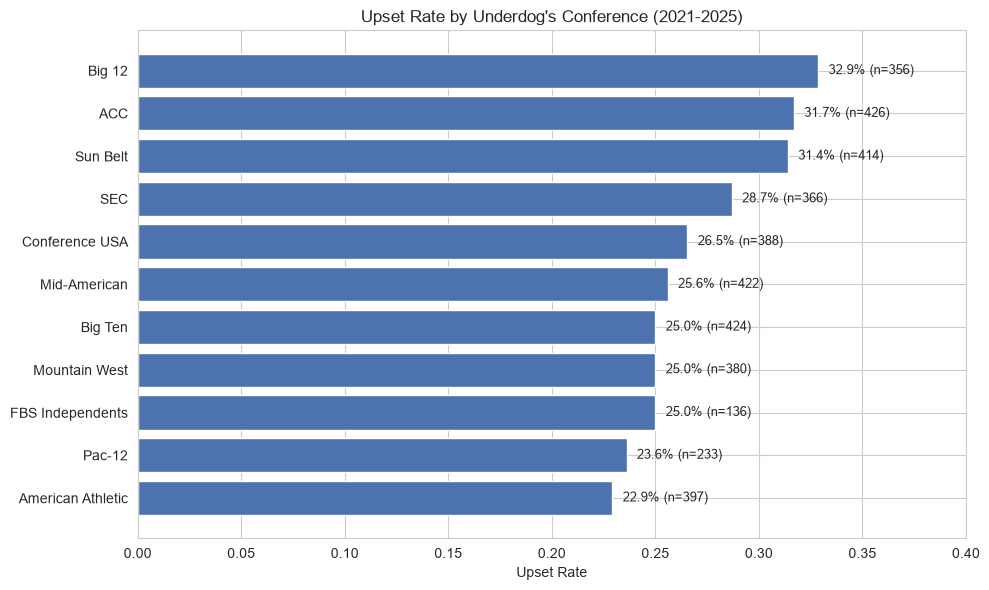

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
conf_sorted = conf_upset_rate.sort_values("mean", ascending=True)

ax.barh(conf_sorted.index, conf_sorted["mean"], color="#4C72B0")
ax.set_xlabel("Upset Rate")
ax.set_title("Upset Rate by Underdog's Conference (2021-2025)")
ax.set_xlim(0, 0.4)

for i, (rate, n) in enumerate(zip(conf_sorted["mean"], conf_sorted["count"])):
    ax.text(rate + 0.005, i, f"{rate:.1%} (n={n})", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/upset_rate_by_conference.png", dpi=150)
plt.show()

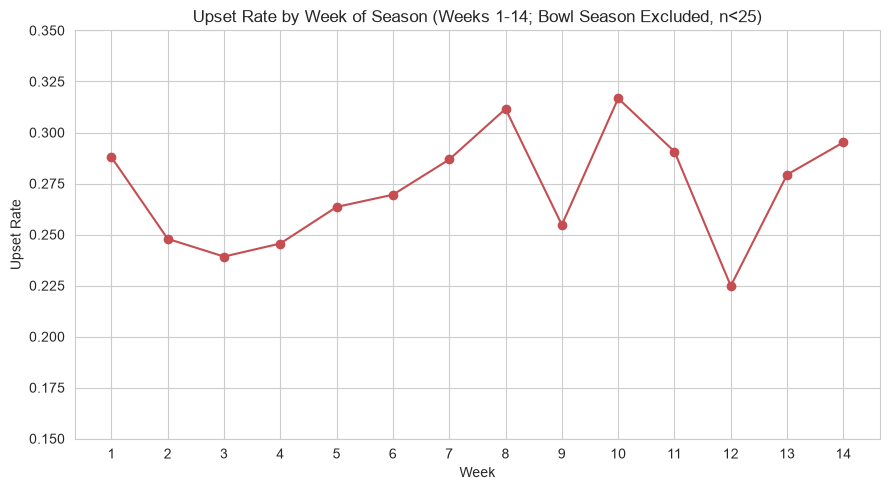

In [13]:
week_trimmed = week_upset_rate[week_upset_rate.index <= 14]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(week_trimmed.index, week_trimmed["mean"], marker="o", color="#C44E52")
ax.set_xlabel("Week")
ax.set_ylabel("Upset Rate")
ax.set_title("Upset Rate by Week of Season (Weeks 1-14; Bowl Season Excluded, n<25)")
ax.set_ylim(0.15, 0.35)
ax.set_xticks(week_trimmed.index)

plt.tight_layout()
plt.savefig("../reports/figures/upset_rate_by_week.png", dpi=150)
plt.show()